<a href="https://colab.research.google.com/github/smorgan-blip/lis4693/blob/main/lab-5/lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Topic Modeling


## Install and Import Packages

In [ ]:
!pip install gensim
!pip install pyldavis
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.1 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/smorgan-blip/lis4693/refs/heads/main/lab-5/bulgaria-md-export.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

Here I imported the data I got from lens.org. The query I used to get the 1,000 articles for this lab was "bulgaria" because I wanted to see what kinds of things were published on the country. As I expected, there was a variety of topics from political articles to scientific research articles in the dataset.

In [ ]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

               Lens ID                                              Title  \
0  000-268-237-593-113  Combined Process of Chlorination Roasting and ...   
1  000-327-018-837-082  Two new species of Euscorpius (Scorpiones: Eus...   
2  000-338-901-308-378                                Occurrence Download   
3  000-444-464-368-194  Denial of access to sexual and reproductive he...   
4  000-601-743-028-48X  Potamophylax rilaensis sp. nov. (Trichoptera: ...   

   Publication Year Publication Type  \
0              2026  journal article   
1              2026          dataset   
2              2026          dataset   
3              2026  journal article   
4              2026          dataset   

                               Source Title  \
0            Materials (Basel, Switzerland)   
1                     The Catalogue of Life   
2  Global Biodiversity Information Facility   
3                       Reproductive health   
4                     The Catalogue of Life   

             

In [ ]:
df = df[["Author/s", "Title", "Abstract"]]
print(df[:10])

                                            Author/s  \
0    Biserka Lucheva; Peter Iliev; Nadezhda Kazakova   
1  Victor Fet; Matthew R. Graham; Michael M. Webb...   
2                                      GBIF.org User   
3                        Elisa Groff; Florian Steger   
4           Halil Ibrahimi; Janos Oláh; Tibor Kovács   
5                                      GBIF.org User   
6  Ioana-Antonia Iftimie; Diana Serbezeanu; Tăchi...   
7                                       Marina Miron   
8  Karekin D. Esmeryan; Yuliyan Lazarov; Gabriela...   
9  Nataliia Iakovenko; Dzmitry Lukashanets; Jolan...   

                                               Title  \
0  Combined Process of Chlorination Roasting and ...   
1  Two new species of Euscorpius (Scorpiones: Eus...   
2                                Occurrence Download   
3  Denial of access to sexual and reproductive he...   
4  Potamophylax rilaensis sp. nov. (Trichoptera: ...   
5                                Occurrence Dow

Here I created a dataframe with the columns Author/s, Title, and Abstract. I then printed the first 10 rows.

In [ ]:
docs = df.Abstract.tolist()
print(docs[0])

This study evaluates an integrated approach for recovering lead and silver from lead cake through chlorination roasting followed by acid leaching. The lead cake originates from sulfuric acid leaching of zinc ferrite residues obtained during the hydrometallurgical processing of zinc calcine. The effects of roasting temperature, lead cake-to-NaCl mass ratio, and roasting duration on metal recovery were systematically examined to determine optimal process conditions. Based on the experimental results, roasting at 550 °C for 1.5 h with a lead cake-to-NaCl mass ratio of 1:3, followed by leaching in 1 M HCl, was selected as a representative and sufficiently effective condition for the combined process. Under these conditions, nearly complete dissolution of Pb and Ag was achieved, reducing their contents in the final solid residue to 0.90% and 0.0027%, respectively. Compared to direct chloride leaching, the combined process provided higher extraction efficiencies (Pb 98.67%, Ag 98.09%) and a 

I chose to use the column Abstract for the data modeling because I thought it would provide the best representation for the content in the articles

## Cleaning Documents


In [ ]:
stop_words = stopwords.words('english')

In [ ]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words


In [ ]:
## Adding custom stopwords

custom_stopwords = ['study', 'data', '—', 'jats', 'jatsp', 'sub', 'l', 'abstracttext', 'pb', 'pbclsub2sub', 'results', 'jatssec', 'analysis', 'research', 'studies']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['study', 'data', '—', 'jats', 'jatsp', 'sub', 'l', 'abstracttext', 'pb', 'pbclsub2sub', 'results', 'jatssec', 'analysis', 'research', 'studies']


In [ ]:
processed_docs = [doc if isinstance(doc, str) and not pd.isna(doc) else '' for doc in docs]

Here I had to do one more step before cleaning the docs. The code below wasn't working because some of the values I had in Abstract were "NaN" which was converted into a float. The code below then didn't work because it couldn't take floats but the line above converted "NaN" back to a string

In [ ]:
cleaned_docs = [clean_doc(doc) for doc in processed_docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
This study evaluates an integrated approach for recovering lead and silver from lead cake through chlorination roasting followed by acid leaching. The lead cake originates from sulfuric acid leaching of zinc ferrite residues obtained during the hydrometallurgical processing of zinc calcine. The effects of roasting temperature, lead cake-to-NaCl mass ratio, and roasting duration on metal recovery were systematically examined to determine optimal process conditions. Based on the experimental results, roasting at 550 °C for 1.5 h with a lead cake-to-NaCl mass ratio of 1:3, followed by leaching in 1 M HCl, was selected as a representative and sufficiently effective condition for the combined process. Under these conditions, nearly complete dissolution of Pb and Ag was achieved, reducing their contents in the final solid residue to 0.90% and 0.0027%, respectively. Compared t

Here's how the first doc in my dataset was cleaned

In [ ]:
cleaned_docs = [clean_doc(doc) for doc in processed_docs]

## Create ID-Word Index


In [ ]:
id2word = corpora.Dictionary(cleaned_docs)

With the ID-Word Index created, let’s query it and see what word maps to index number `250`.

In [ ]:
id2word[250]

'complexity'

In [ ]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

In [ ]:
print(corpus[0])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 3), (15, 4), (16, 1), (17, 1), (18, 1), (19, 2), (20, 2), (21, 1), (22, 2), (23, 1), (24, 3), (25, 1), (26, 1), (27, 1), (28, 1), (29, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 2), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 2), (54, 2), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 2), (65, 1), (66, 7), (67, 5), (68, 1), (69, 2), (70, 3), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 4), (87, 1), (88, 1), (89, 1), (90, 1), (91, 4), (92, 1), (93, 2), (94, 1), (95, 1), (96, 1), (97, 1), (98, 4), (99, 2), (100, 1), (101, 1), (102, 5), (103, 1), (104, 1), (105, 1), (106, 1), (107, 1), (108, 1), (109, 1), (110, 1),

Here we created the ID-Word index from my cleaned_docs. For each doc, it gives each unique word a number and sorts it alphabetically. This is what our LDA model will expect instead of the original sequence of words

In [ ]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	00027
1	090
2	1
3	110
4	1100
5	124572
6	13
7	15
8	34
9	45
10	550
11	9809
12	9867
13	achieved
14	acid
15	ag
16	approach
17	aqueous
18	based
19	cake
20	caketonacl
21	calcine
22	chloride
23	chlorination
24	combined
25	compared
26	complete
27	compliance
28	condition
29	conditions
30	confirmed
31	contents
32	conversion
33	criteria
34	determine
35	direct
36	dissolution
37	duration
38	effective
39	effects
40	efficiencies
41	en
42	enables
43	enhances
44	ensures
45	environmental
46	eu
47	evaluates
48	examined
49	experimental
50	extraction
51	ferrite
52	fesub2subosub3sub
53	final
54	followed
55	form
56	h
57	hcl
58	high
59	higher
60	highly
61	hydrometallurgical
62	incomplete
63	industrial
64	inert
65	integrated
66	leaching
67	lead
68	leadcontaining
69	lower
70	mass
71	matrix
72	meets
73	metal
74	minimizes
75	nearcomplete
76	nearly
77	obtained
78	offers
79	optimal
80	optimized
81	originates
82	overall
83	pbohcl
84	pbsosub4sub
85	phases
86	process
87	processing
88	produced
89	proposed
90	provided

## Creating LDA Topic Model


In [ ]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, passes = 10, num_topics=10)

This is my first time training my model. I've set the number of topics to 10 and the first time I tried this it said to increase the number of passes or iterations so I included the number of passes as 10.

## Analyze a Document


In [ ]:
topics = lda_model.get_document_topics(corpus)
len(topics)

1000

In [ ]:
for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

(6, 0.9948500394821167)


Here I printed the topics found in the first document. Because my model only set 10 topics, only one applied to this document.

In [ ]:
print(docs[0])

This study evaluates an integrated approach for recovering lead and silver from lead cake through chlorination roasting followed by acid leaching. The lead cake originates from sulfuric acid leaching of zinc ferrite residues obtained during the hydrometallurgical processing of zinc calcine. The effects of roasting temperature, lead cake-to-NaCl mass ratio, and roasting duration on metal recovery were systematically examined to determine optimal process conditions. Based on the experimental results, roasting at 550 °C for 1.5 h with a lead cake-to-NaCl mass ratio of 1:3, followed by leaching in 1 M HCl, was selected as a representative and sufficiently effective condition for the combined process. Under these conditions, nearly complete dissolution of Pb and Ag was achieved, reducing their contents in the final solid residue to 0.90% and 0.0027%, respectively. Compared to direct chloride leaching, the combined process provided higher extraction efficiencies (Pb 98.67%, Ag 98.09%) and a 

In [ ]:
for topic in topics[0][:10]:
    terms = lda_model.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(6, 0.9948499798774719)
1540 genetic
13077 slavic
1127 al
1722 population
1135 et



Here I printed the top 5 words for each topic in the first document. Because there were only 10 topics in this model, only 1 applied to this document so it only had results in one topic to print.

Next, I will train a model on 20 topics instead of 10 to see if the results are different.

In [ ]:
lda_model = LdaModel(corpus=corpus, id2word=id2word, passes = 10, num_topics=20)

In [ ]:
topics = lda_model.get_document_topics(corpus)
len(topics)

1000

In [ ]:
for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

(6, 0.9948499798774719)


In [ ]:
print(docs[0])

This study evaluates an integrated approach for recovering lead and silver from lead cake through chlorination roasting followed by acid leaching. The lead cake originates from sulfuric acid leaching of zinc ferrite residues obtained during the hydrometallurgical processing of zinc calcine. The effects of roasting temperature, lead cake-to-NaCl mass ratio, and roasting duration on metal recovery were systematically examined to determine optimal process conditions. Based on the experimental results, roasting at 550 °C for 1.5 h with a lead cake-to-NaCl mass ratio of 1:3, followed by leaching in 1 M HCl, was selected as a representative and sufficiently effective condition for the combined process. Under these conditions, nearly complete dissolution of Pb and Ag was achieved, reducing their contents in the final solid residue to 0.90% and 0.0027%, respectively. Compared to direct chloride leaching, the combined process provided higher extraction efficiencies (Pb 98.67%, Ag 98.09%) and a 

In [ ]:
for topic in topics[0][:19]:
    terms = lda_model.get_topic_terms(topic[0], 5)
    print(f"({topic[0]}, {float(topic[1])})")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(6, 0.9948499798774719)
16249 bombus
1524 control
1703 group
2508 lt
1305 significant



Here we now see that there are 3 topic matches for the first document instead of just 1. This shows that the content is broken into more specific topics which can cluster information into stronger groups. I think the model trained to have more topics (20) ended up working better because the quality and quantity of information given was better. You got a more detailed representation of the content in docs because of the more specific topics and you get more information when you have multiple topics to anyalyze.

## Visualize Topics

In [ ]:
topic_data = []
target_topic_ids = [4, 9, 14, 19]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID       Word  Probability
0         4     health     0.003806
1         4         de     0.003426
2         4  bulgarian     0.003380
3         4   bulgaria     0.003069
4         4   european     0.002765


Here I converted the topic words and probabilities for topics 5, 10, 15, and 20 into dataframes

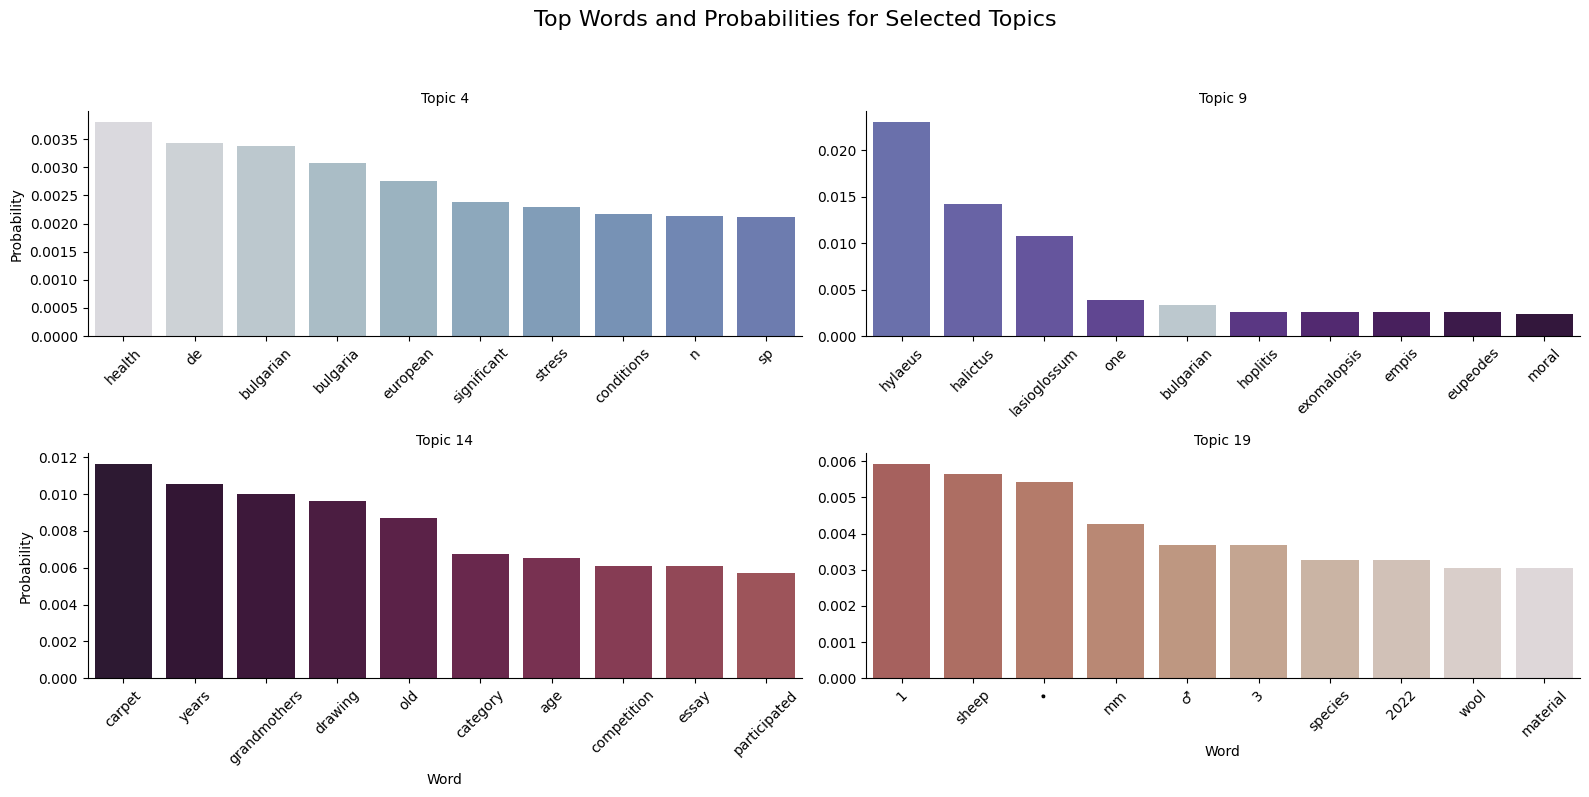

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Here are the bar graph visualizations for the 4 topics I made dataframes for. These are the labels I would give each topic:

Topic 4: Stress and Bulgarian Health

Topic 9: Bee Species

Topic 14: Bulgarian Grandmothers/Elders

Topic 19: Sheep wool

I'd say of these four, the topic of bee species was probably most distinct.

All of them are very different, but I think the topic on Bulgarian Health could overlap with the topic on Bulgarian Grandmothers/Elders which could also overlap with Sheep Wool (because of the keyword carpets--weaving).

These top keywords did not align with my expectations because I did not think there would be topics so niche. It appears as though there were probably larger categories such as health and politics and then small unique topics with the remaining few documents

In [ ]:
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word, mds="mmds", R=30)

In [ ]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
5     -0.331948 -0.180191       1        1  9.000073
0     -0.179739  0.036617       2        1  7.835864
12    -0.049540 -0.080097       3        1  7.335024
16    -0.064767 -0.278300       4        1  7.293039
2      0.035167  0.178494       5        1  6.921656
6     -0.067719  0.061907       6        1  6.564455
4     -0.150252  0.133857       7        1  5.173060
3     -0.125031 -0.155056       8        1  4.748078
17     0.045765 -0.213659       9        1  4.644715
11     0.210142 -0.237147      10        1  4.556010
13     0.074460 -0.125004      11        1  4.437186
1      0.145789  0.202199      12        1  4.420672
8     -0.323098 -0.010071      13        1  4.409630
18     0.055700  0.057151      14        1  4.180424
9     -0.155327  0.262955      15        1  3.636281
19    -0.005909  0.290224      16        1  3.604691
15     0.171774 -0.076339      17        1  3.576166
10     0.299562 -0.039068      18        1  2.870455
7      0.170749  0.042671      19        1  2.535965
14     0.244222  0.128856      20        1  2.256556, topic_info=          Term        Freq       Total Category  logprob  loglift
143    country  258.000000  258.000000  Default  30.0000  30.0000
3418   andrena  130.000000  130.000000  Default  29.0000  29.0000
6931   hylaeus   82.000000   82.000000  Default  28.0000  28.0000
149   datasets  130.000000  130.000000  Default  27.0000  27.0000
148    dataset  177.000000  177.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
191    moldova    6.613774   63.028987  Topic20  -5.8071   1.5369
2048         •    6.135857   56.308815  Topic20  -5.8821   1.5746
208   republic    6.975608  138.217857  Topic20  -5.7538   0.8049
394    changes    5.327103   63.204835  Topic20  -6.0234   1.3178
379       also    5.340430  129.001720  Topic20  -6.0209   0.6068

[1277 rows x 6 columns], token_table=       Topic      Freq Term
term                       
2          1  0.092126    1
2          2  0.051181    1
2          3  0.010236    1
2          4  0.061417    1
2          5  0.112598    1
...      ...       ...  ...
2048      20  0.106555    •
12719      6  0.362693    →
12719      9  0.604488    →
2049      16  0.899996    ♀
2050      16  0.940023    ♂

[4758 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 1, 13, 17, 3, 7, 5, 4, 18, 12, 14, 2, 9, 19, 10, 20, 16, 11, 8, 15])

This lab was very interesting because I learned how to work with a model that determined its own categories to see how best to set things up to get useful results. I learned it was better to have more topics so you could describe documents for specifically and that removing stop words was important to clustering the important words that actually carried content. That being said, things still did not go how I expected with my dataset because I wasn't familiar with what was inside, so I had to keep adjusting the stop words to remove and still didn't know what topics should be represented.

Still, it was a very interesting lab and I think I could use this in the future if I ever needed to do exploratory research. I don't think my future career would use this but if I ever wanted to learn about a larger topic I could use topic modelling to learn about how documents in a dataset grouped into common topics and learn more about what a large subject consists of. That would be helpful to know what I wanted to look into further and I'd be able to see which documents were categorized with the topic.